<a href="https://colab.research.google.com/github/Lordvaderani/shors-algo-qasm-project/blob/main/grover.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:


!pip install qiskit qiskit-aer matplotlib pylatexenc
!pip install qiskit_qasm3_import

Running simulation...
Measurement Counts: {'110': 250939, '100': 249590, '000': 249686, '010': 249785}


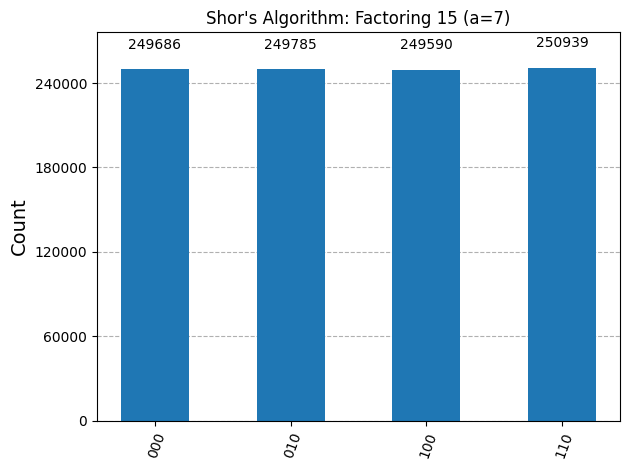

In [2]:
from qiskit import qasm3
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 1. The complete OpenQASM 3.0 string
qasm_string = """
OPENQASM 3.0;
include "stdgates.inc";

// Define 7 qubits and 3 classical bits for measurement
qubit[7] q;
bit[3] c;

// --- INITIALIZATION ---
// Put the counting register in superposition
h q[0];
h q[1];
h q[2];
// Set target register to |0001>
x q[3];

// --- ORACLE: Calculate 7^x mod 15 ---
// Multiply by 7 (Controlled by q[0])
cswap q[0], q[3], q[6];
cswap q[0], q[3], q[5];
cswap q[0], q[3], q[4];
cx q[0], q[3];
cx q[0], q[4];
cx q[0], q[5];
cx q[0], q[6];

// Multiply by 4 (Controlled by q[1])
cswap q[1], q[3], q[5];
cswap q[1], q[4], q[6];

// Multiply by 16 (Controlled by q[2]) - Does nothing (16 mod 15 = 1)

// --- INVERSE QUANTUM FOURIER TRANSFORM (CORRECTED) ---
// 1. Undo wire order
swap q[0], q[2];

// 2. Unwind q[0] first
h q[0];

// 3. Unwind q[1]
cp(-pi/2) q[0], q[1];
h q[1];

// 4. Unwind q[2]
cp(-pi/4) q[0], q[2];
cp(-pi/2) q[1], q[2];
h q[2];

// --- MEASUREMENT ---
c[0] = measure q[0];
c[1] = measure q[1];
c[2] = measure q[2];
"""

# 2. Parse the QASM 3 string into a Qiskit QuantumCircuit
circuit = qasm3.loads(qasm_string)

# 3. Set up the local Aer Simulator
simulator = AerSimulator()

# 4. Execute the circuit (1024 shots)
print("Running simulation...")
job = simulator.run(circuit, shots=1000000)
result = job.result()
%matplotlib inline
# 5. Extract and display the results
counts = result.get_counts()
print(f"Measurement Counts: {counts}")

# 6. Render the histogram in Colab (This must be the absolute last line!)
plot_histogram(counts, title="Shor's Algorithm: Factoring 15 (a=7)")

In [ ]:
from qiskit import qasm3
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 1. The complete OpenQASM 3.0 string
qasm_string = """
OPENQASM 3.0;
include "stdgates.inc";

qubit[4] q;
bit[3] c; // Only 3 classical bits needed for the compute qubits

// --- 1. Initialization ---
reset q; // Resets all qubits to |0>

// Put compute qubits in an equal superposition
h q[0];
h q[1];
h q[2];

// Initialize the ancilla (q[3]) to the |-> state for phase kickback
x q[3];
h q[3];

// --- 2. The Oracle ---
// Marks the state 110 (q[2]=1, q[1]=1, q[0]=0)
x q[1];
ctrl @ ccx q[2], q[1], q[0], q[3]; // 3-Controlled X targeting q[3]
x q[1];

// --- 3. The Diffuser (Inversion about the Mean) ---
// Apply H to compute register
h q[0];
h q[1];
h q[2];

// Apply X to compute register
x q[0];
x q[1];
x q[2];

// Multi-controlled Z gate (CCZ)
ctrl @ ctrl @ z q[0], q[1], q[2];

// Undo X on compute register
x q[0];
x q[1];
x q[2];

// Undo H on compute register
h q[0];
h q[1];
h q[2];

// --- 4. Measurement ---
// Collapse the superposition to reveal the target state (110)
c[0] = measure q[0];
c[1] = measure q[1];
c[2] = measure q[2];
"""

# 2. Parse the QASM 3 string into a Qiskit QuantumCircuit
circuit = qasm3.loads(qasm_string)

# 3. Set up the local Aer Simulator
simulator = AerSimulator()

# 4. Execute the circuit (1024 shots)
print("Running simulation...")
job = simulator.run(circuit, shots=1000000)
result = job.result()
%matplotlib inline
# 5. Extract and display the results
counts = result.get_counts()
print(f"Measurement Counts: {counts}")

# 6. Render the histogram in Colab (This must be the absolute last line!)
plot_histogram(counts, title="grovers")